In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
import cv2 # Chỉ dùng để đọc ảnh thực và so sánh kết quả [cite: 60, 63]

%matplotlib inline

In [2]:
def gaussian_blur(image, sigma):
    size = int(2 * np.ceil(3 * sigma) + 1)
    x, y = np.mgrid[-size//2 + 1:size//2 + 1, -size//2 + 1:size//2 + 1]
    g = np.exp(-(x**2 + y**2) / (2.0 * sigma**2))
    kernel = g / g.sum()
    return convolve(image, kernel)

In [3]:
def compute_gradients(image):
    # Tự tạo kernel Sobel [cite: 56]
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float32)
    Ky = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], np.float32)
    
    Gx = convolve(image, Kx)
    Gy = convolve(image, Ky)
    
    magnitude = np.hypot(Gx, Gy)
    # Chuyển radian sang độ và đưa về khoảng [0, 180]
    angle = np.arctan2(Gy, Gx) * 180.0 / np.pi
    angle[angle < 0] += 180
    
    return magnitude, angle

In [4]:
def non_max_suppression(magnitude, angle):
    M, N = magnitude.shape
    Z = np.zeros((M, N), dtype=np.float32)
    
    for i in range(1, M-1):
        for j in range(1, N-1):
            curr_angle = angle[i, j]
            q, r = 255, 255 # Giá trị hàng xóm
            
            # Hướng 0 (ngang)
            if (0 <= curr_angle < 22.5) or (157.5 <= curr_angle <= 180):
                q, r = magnitude[i, j+1], magnitude[i, j-1]
            # Hướng 45 (chéo phải)
            elif (22.5 <= curr_angle < 67.5):
                q, r = magnitude[i+1, j-1], magnitude[i-1, j+1]
            # Hướng 90 (dọc)
            elif (67.5 <= curr_angle < 112.5):
                q, r = magnitude[i+1, j], magnitude[i-1, j]
            # Hướng 135 (chéo trái)
            elif (112.5 <= curr_angle < 157.5):
                q, r = magnitude[i-1, j-1], magnitude[i+1, j+1]

            if (magnitude[i, j] >= q) and (magnitude[i, j] >= r):
                Z[i, j] = magnitude[i, j]
            else:
                Z[i, j] = 0
    return Z

In [5]:
def hysteresis(image, t_low, t_high):
    M, N = image.shape
    res = np.zeros((M, N), dtype=np.int32)
    
    strong = 255
    weak = 50
    
    strong_i, strong_j = np.where(image >= t_high)
    weak_i, weak_j = np.where((image <= t_high) & (image >= t_low))
    
    res[strong_i, strong_j] = strong
    res[weak_i, weak_j] = weak
    
    # Kiểm tra 8-liên thông [cite: 53]
    for i in range(1, M-1):
        for j in range(1, N-1):
            if res[i, j] == weak:
                # Nếu xung quanh có ít nhất 1 pixel strong
                if (res[i-1:i+2, j-1:j+2] == strong).any():
                    res[i, j] = strong
                else:
                    res[i, j] = 0
    return res

In [6]:
def my_canny(image, sigma, t_low, t_high):
    # Bước 1: Làm mịn
    smoothed = gaussian_blur(image, sigma)
    # Bước 2: Gradient
    mag, ang = compute_gradients(smoothed)
    # Bước 3: NMS
    nms_img = non_max_suppression(mag, ang)
    # Bước 4: Hysteresis
    final_img = hysteresis(nms_img, t_low, t_high)
    return final_img

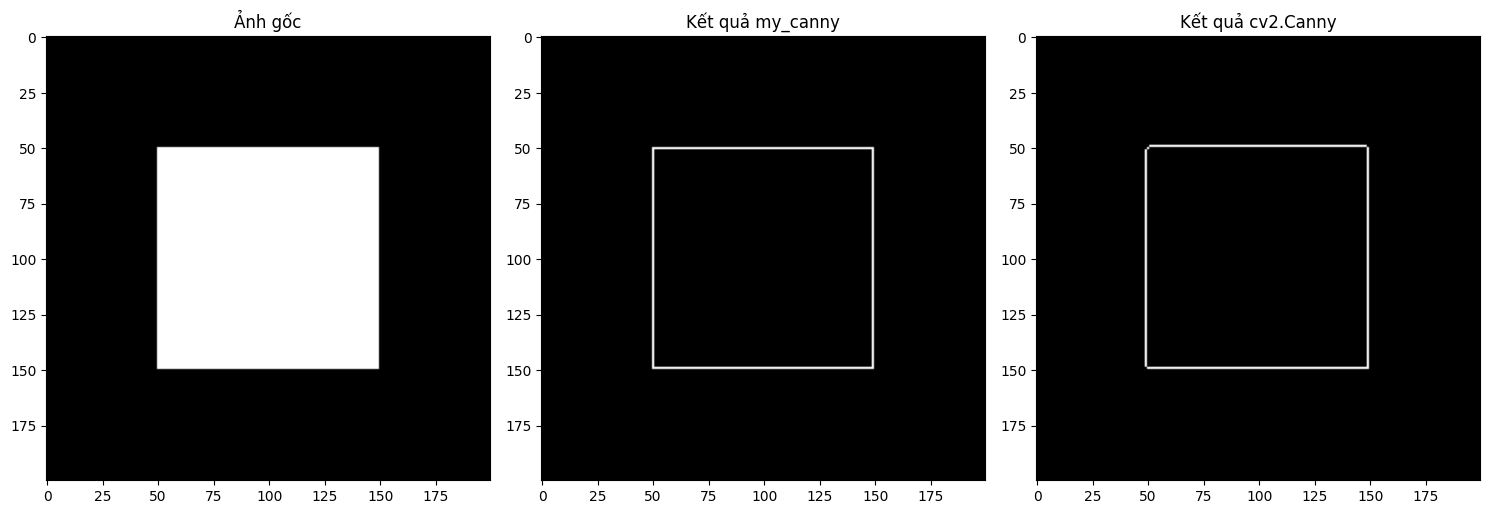

In [7]:
# Tạo ảnh tổng hợp (hình chữ nhật trắng trên nền đen) [cite: 60]
test_img = np.zeros((200, 200), dtype=np.float32)
test_img[50:150, 50:150] = 255

# Thực thi thuật toán
sigma, low, high = 1.4, 30, 80
custom_res = my_canny(test_img, sigma, low, high)
opencv_res = cv2.Canny(test_img.astype(np.uint8), low, high)

# Hiển thị song song [cite: 63]
plt.figure(figsize=(15, 5))
plt.subplot(131); plt.title("Ảnh gốc"); plt.imshow(test_img, cmap='gray')
plt.subplot(132); plt.title("Kết quả my_canny"); plt.imshow(custom_res, cmap='gray')
plt.subplot(133); plt.title("Kết quả cv2.Canny"); plt.imshow(opencv_res, cmap='gray')
plt.tight_layout()
plt.show()